
<h2 id="1.4-TTree-%E7%9A%84-MakeClass-%E6%96%B9%E6%B3%95">1.4 TTree 的 MakeClass 方法</h2><ul>
<li>MakeClass方法提供了访问ROOT文件的TTree内部数据所需的类(class)的结构</li>
</ul>
<h3 id="1.-%E6%89%8B%E5%8A%A8%E7%BC%96%E5%86%99%E9%80%90%E4%BA%8B%E4%BB%B6%E8%AF%BB%E5%8F%96ROOT%E6%96%87%E4%BB%B6%E5%88%86%E6%9E%90">1. 手动编写逐事件读取ROOT文件分析</h3><ul>
<li>用户需要手动管理内存变量与磁盘数据分支（Branch）的映射， 这种方式在分支较少时可行。。</li>
</ul>
<div class="highlight"><pre><span></span><span class="kt">void</span><span class="w"> </span><span class="nf">Analyze</span><span class="p">()</span><span class="w"> </span><span class="p">{</span>
<span class="w">    </span><span class="c1">// 1. 声明本地工作区变量</span>
<span class="w">    </span><span class="n">Int_t</span><span class="w"> </span><span class="n">raw_pid</span><span class="p">;</span><span class="w"> </span>
<span class="w">    </span><span class="n">Double_t</span><span class="w"> </span><span class="n">raw_tL</span><span class="p">,</span><span class="w"> </span><span class="n">raw_tR</span><span class="p">;</span><span class="w"> </span>

<span class="w">    </span><span class="c1">// 2. 手动绑定地址：将磁盘 Branch 映射到内存变量地址</span>
<span class="w">    </span><span class="n">tIn</span><span class="o">-&gt;</span><span class="n">SetBranchAddress</span><span class="p">(</span><span class="s">"pid"</span><span class="p">,</span><span class="w"> </span><span class="o">&amp;</span><span class="n">raw_pid</span><span class="p">);</span>
<span class="w">    </span><span class="n">tIn</span><span class="o">-&gt;</span><span class="n">SetBranchAddress</span><span class="p">(</span><span class="s">"tL"</span><span class="p">,</span><span class="w">  </span><span class="o">&amp;</span><span class="n">raw_tL</span><span class="p">);</span>
<span class="w">    </span><span class="c1">// ... 若有几十个分支，此处将极其冗长</span>
<span class="p">}</span>
</pre></div>
<ul>
<li>但当处理复杂的 ROOT 文件（如包含多维数组或数十个物理量分支）时，手动编写变量声明和 <code>SetBranchAddress</code> 既繁琐又极易出错。</li>
</ul>


In [2]:
TFile *ipf = new TFile("run0005.root"); 
TTree *tree = (TTree*)  ipf->Get("tree");
tree->Print();

******************************************************************************
*Tree    :tree      : tree must2                                             *
*Entries :   511950 : Total =       917722277 bytes  File  Size =  306046164 *
*        :          : Tree compression factor =   3.00                       *
******************************************************************************
*Br    0 :beamTrig  : beamTrig/I                                             *
*Entries :   511950 : Total  Size=    2049732 bytes  File Size  =      93041 *
*Baskets :       17 : Basket Size=     519680 bytes  Compression=  22.02     *
*............................................................................*
*Br    1 :must2Trig : must2Trig[8]/I                                         *
*Entries :   511950 : Total  Size=   16389351 bytes  File Size  =    1021856 *
*Baskets :       69 : Basket Size=    1369600 bytes  Compression=  16.04     *
*...................................................


<h3 id="2.-MakeClass%EF%BC%9A%E8%87%AA%E5%8A%A8%E5%8C%96%E4%BB%A3%E7%A0%81%E7%94%9F%E6%88%90%E5%99%A8">2. MakeClass：自动化代码生成器</h3><p><code>MakeClass</code> 的核心作用是自动化数据映射。它通过扫描 <code>TTree</code> 的拓扑结构，自动生成一个包含所有变量定义、底层数据连接以及分析循环框架的 C++ 类。</p>
<p><strong>生成方式：</strong>
在 ROOT 终端执行：</p>


In [4]:
tree->MakeClass("ppac");

Info in <TTreePlayer::MakeClass>: Files: ppac.h and ppac.C generated from TTree: tree


<p>ROOT 会生成 <code>ppac.h</code> 和 <code>ppac.C</code>。<strong>类 <code>ppac</code> 定义了该实验数据的结构及其操作接口，可以被视为一个自定义的高级数据类型。</strong></p>
<h3 id="3.-ppac.h%EF%BC%9A%E7%B1%BB%E7%9A%84%E5%A3%B0%E6%98%8E%E4%B8%8E%E6%88%90%E5%91%98%E5%AE%9A%E4%B9%89">3. ppac.h：类的声明与成员定义</h3><p><code>ppac.h</code> 负责定义数据的“模样”。根据源代码，其实际结构如下：</p>
<p><strong>A. 成员变量（数据存放区）</strong>
类内部自动声明了与 Tree 分支完全对应的变量。相比传统做法，它能自动处理复杂的数组维度。</p>
<div class="highlight"><pre><span></span><span class="cp">#ifndef ppac_h</span>
<span class="cp">#define ppac_h</span>

<span class="cp">#include</span><span class="w"> </span><span class="cpf">&lt;TROOT.h&gt;</span>
<span class="cp">#include</span><span class="w"> </span><span class="cpf">&lt;TChain.h&gt;</span>
<span class="cp">#include</span><span class="w"> </span><span class="cpf">&lt;TFile.h&gt;</span>

<span class="k">class</span><span class="w"> </span><span class="nc">ppac</span><span class="w"> </span><span class="p">{</span>
<span class="k">public</span><span class="w"> </span><span class="o">:</span>
<span class="w">   </span><span class="n">TTree</span><span class="w">          </span><span class="o">*</span><span class="n">fChain</span><span class="p">;</span><span class="w">   </span><span class="c1">//! 指向当前 TTree 或 TChain 的指针</span>
<span class="w">   </span><span class="n">Int_t</span><span class="w">           </span><span class="n">fCurrent</span><span class="p">;</span><span class="w"> </span><span class="c1">//! 当前 Tree 在 Chain 中的编号</span>

<span class="w">   </span><span class="c1">// --- 自动生成的 Leaf (叶子) 变量 ---</span>
<span class="w">   </span><span class="n">Int_t</span><span class="w">           </span><span class="n">beamTrig</span><span class="p">;</span>
<span class="w">   </span><span class="n">Int_t</span><span class="w">           </span><span class="n">must2Trig</span><span class="p">[</span><span class="mi">8</span><span class="p">];</span>
<span class="w">   </span><span class="n">Float_t</span><span class="w">         </span><span class="n">F8PPACRawData</span><span class="p">[</span><span class="mi">5</span><span class="p">][</span><span class="mi">10</span><span class="p">];</span><span class="w"> </span><span class="c1">// 自动处理了数组维度</span>
<span class="w">   </span><span class="n">Float_t</span><span class="w">         </span><span class="n">AoQ</span><span class="p">[</span><span class="mi">9</span><span class="p">][</span><span class="mi">4</span><span class="p">];</span>
<span class="w">   </span><span class="c1">// ... </span>

<span class="w">   </span><span class="c1">// 【用户扩展】：你可以在此处手动添加自定义变量</span>
<span class="w">   </span><span class="c1">// 例如：Double_t x_cal; 它们将成为 ppac 类型的一部分</span>
</pre></div>
<p><strong>B. 成员函数（操作接口声明）</strong>
类不仅包含数据，还定义了操作数据的函数：</p>
<div class="highlight"><pre><span></span><span class="w">   </span><span class="c1">// --- 自动生成的成员函数 ---</span>
<span class="w">   </span><span class="n">ppac</span><span class="p">(</span><span class="n">TTree</span><span class="w"> </span><span class="o">*</span><span class="n">tree</span><span class="o">=</span><span class="mi">0</span><span class="p">);</span><span class="w">           </span><span class="c1">// 构造函数：用于初始化</span>
<span class="w">   </span><span class="k">virtual</span><span class="w"> </span><span class="o">~</span><span class="n">ppac</span><span class="p">();</span><span class="w">               </span><span class="c1">// 析构函数：用于清理资源</span>
<span class="w">   </span><span class="k">virtual</span><span class="w"> </span><span class="n">Int_t</span><span class="w">    </span><span class="nf">GetEntry</span><span class="p">(</span><span class="n">Long64_t</span><span class="w"> </span><span class="n">entry</span><span class="p">);</span><span class="w">      </span><span class="c1">// 读取数据</span>
<span class="w">   </span><span class="k">virtual</span><span class="w"> </span><span class="kt">void</span><span class="w">     </span><span class="nf">Init</span><span class="p">(</span><span class="n">TTree</span><span class="w"> </span><span class="o">*</span><span class="n">tree</span><span class="p">);</span><span class="w">             </span><span class="c1">// 核心：执行地址绑定</span>
<span class="w">   </span><span class="k">virtual</span><span class="w"> </span><span class="kt">void</span><span class="w">     </span><span class="nf">Loop</span><span class="p">();</span><span class="w">                        </span><span class="c1">// 主分析循环</span>
<span class="w">   </span><span class="k">virtual</span><span class="w"> </span><span class="kt">void</span><span class="w">     </span><span class="nf">Show</span><span class="p">(</span><span class="n">Long64_t</span><span class="w"> </span><span class="n">entry</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">-1</span><span class="p">);</span><span class="w">     </span><span class="c1">// 打印数据</span>
<span class="w">   </span>
<span class="w">   </span><span class="c1">// 【用户扩展】：你可以在此处声明新的成员函数，例如 virtual void Calibrate();</span>
<span class="p">};</span>
</pre></div>
<hr/>
<h4 id="%E6%9E%84%E9%80%A0%E5%87%BD%E6%95%B0%E4%B8%8E-Init()">构造函数与 Init()</h4><p><strong>构造函数 (Constructor)</strong>
在 <code>ppac.h</code> 的实现部分（<code>#ifdef ppac_cxx</code>），定义了类的<strong>构造函数</strong>。</p>
<ul>
<li><strong>含义</strong>：它是类诞生的“初始化程序”。</li>
<li><strong>触发时机</strong>：<strong>一旦类被实例化（创建对象），构造函数就会立即自动运行。</strong></li>
<li><strong>源代码实现</strong>：如果实例化时不传入任何参数（tree == 0），构造函数会默认去打开生成该类时的原始文件（run0005.root），并立即调用 Init(tree) 自动完成所有的 SetBranchAddress 映射工作。</li>
</ul>
<div class="highlight"><pre><span></span><span class="n">ppac</span><span class="o">::</span><span class="n">ppac</span><span class="p">(</span><span class="n">TTree</span><span class="w"> </span><span class="o">*</span><span class="n">tree</span><span class="p">)</span><span class="w"> </span><span class="o">:</span><span class="w"> </span><span class="n">fChain</span><span class="p">(</span><span class="mi">0</span><span class="p">)</span><span class="w"> </span>
<span class="p">{</span>
<span class="w">   </span><span class="k">if</span><span class="w"> </span><span class="p">(</span><span class="n">tree</span><span class="w"> </span><span class="o">==</span><span class="w"> </span><span class="mi">0</span><span class="p">)</span><span class="w"> </span><span class="p">{</span>
<span class="w">      </span><span class="c1">// 自动连接生成代码时的原始文件 run0005.root</span>
<span class="w">      </span><span class="n">TFile</span><span class="w"> </span><span class="o">*</span><span class="n">f</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="p">(</span><span class="n">TFile</span><span class="o">*</span><span class="p">)</span><span class="n">gROOT</span><span class="o">-&gt;</span><span class="n">GetListOfFiles</span><span class="p">()</span><span class="o">-&gt;</span><span class="n">FindObject</span><span class="p">(</span><span class="s">"run0005.root"</span><span class="p">);</span>
<span class="w">      </span><span class="k">if</span><span class="w"> </span><span class="p">(</span><span class="o">!</span><span class="n">f</span><span class="w"> </span><span class="o">||</span><span class="w"> </span><span class="o">!</span><span class="n">f</span><span class="o">-&gt;</span><span class="n">IsOpen</span><span class="p">())</span><span class="w"> </span><span class="p">{</span><span class="w"> </span><span class="n">f</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="k">new</span><span class="w"> </span><span class="n">TFile</span><span class="p">(</span><span class="s">"run0005.root"</span><span class="p">);</span><span class="w"> </span><span class="p">}</span>
<span class="w">      </span><span class="n">f</span><span class="o">-&gt;</span><span class="n">GetObject</span><span class="p">(</span><span class="s">"tree"</span><span class="p">,</span><span class="n">tree</span><span class="p">);</span>
<span class="w">   </span><span class="p">}</span>
<span class="w">   </span><span class="n">Init</span><span class="p">(</span><span class="n">tree</span><span class="p">);</span><span class="w"> </span><span class="c1">// 实例化时立即执行关键的地址绑定</span>
<span class="p">}</span>
</pre></div>
<p><strong>Init() 函数</strong>
<code>Init()</code> 实现了传统做法中所有的 <code>SetBranchAddress</code> 操作，将磁盘数据流导向类成员变量。</p>
<div class="highlight"><pre><span></span><span class="kt">void</span><span class="w"> </span><span class="nf">ppac::Init</span><span class="p">(</span><span class="n">TTree</span><span class="w"> </span><span class="o">*</span><span class="n">tree</span><span class="p">)</span>
<span class="p">{</span>
<span class="w">   </span><span class="k">if</span><span class="w"> </span><span class="p">(</span><span class="o">!</span><span class="n">tree</span><span class="p">)</span><span class="w"> </span><span class="k">return</span><span class="p">;</span>
<span class="w">   </span><span class="n">fChain</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="n">tree</span><span class="p">;</span>
<span class="w">   </span><span class="n">fChain</span><span class="o">-&gt;</span><span class="n">SetMakeClass</span><span class="p">(</span><span class="mi">1</span><span class="p">);</span>

<span class="w">   </span><span class="c1">// 自动生成的地址绑定代码：将 Branch 名称与类成员变量地址关联</span>
<span class="w">   </span><span class="n">fChain</span><span class="o">-&gt;</span><span class="n">SetBranchAddress</span><span class="p">(</span><span class="s">"beamTrig"</span><span class="p">,</span><span class="w"> </span><span class="o">&amp;</span><span class="n">beamTrig</span><span class="p">,</span><span class="w"> </span><span class="o">&amp;</span><span class="n">b_beamTrig</span><span class="p">);</span>
<span class="w">   </span><span class="n">fChain</span><span class="o">-&gt;</span><span class="n">SetBranchAddress</span><span class="p">(</span><span class="s">"F8PPACRawData"</span><span class="p">,</span><span class="w"> </span><span class="n">F8PPACRawData</span><span class="p">,</span><span class="w"> </span><span class="o">&amp;</span><span class="n">b_F8PPACRawData</span><span class="p">);</span>
<span class="w">   </span><span class="c1">// ... </span>
<span class="p">}</span>
</pre></div>
<p><strong><code>fChain</code>：它是类内部访问 Tree 的全局接口。所有的读取操作（如 GetEntry）最终都通过 fChain 执行。</strong></p>
<p><strong>Loop() 函数</strong></p>
<ul>
<li>读入事件信息进行进一步处理。其具体实现在<code>ppac.C</code></li>
</ul>
<hr/>
<h3 id="4.-ppac.C%EF%BC%9A%E7%89%A9%E7%90%86%E9%80%BB%E8%BE%91%E5%AE%9E%E7%8E%B0">4. ppac.C：物理逻辑实现</h3><p><code>ppac.C</code> 提供了物理逻辑的存放位置。</p>
<ul>
<li><strong>#include "ppac.h"</strong>：在 <code>ppac.C</code> 开头引入头文件。这意味着 <code>ppac.C</code> 获得了 <code>ppac.h</code> 中定义的所有变量和函数接口。</li>
</ul>
<p><strong>原始 Loop() 框架</strong></p>
<p>生成的原始代码是一个空循环，展示了标准的数据读取流程：</p>
<div class="highlight"><pre><span></span><span class="cp">#define ppac_cxx</span>
<span class="cp">#include</span><span class="w"> </span><span class="cpf">"ppac.h"</span>

<span class="kt">void</span><span class="w"> </span><span class="nf">ppac::Loop</span><span class="p">()</span><span class="w"> </span><span class="p">{</span>
<span class="w">   </span><span class="k">if</span><span class="w"> </span><span class="p">(</span><span class="n">fChain</span><span class="w"> </span><span class="o">==</span><span class="w"> </span><span class="mi">0</span><span class="p">)</span><span class="w"> </span><span class="k">return</span><span class="p">;</span>
<span class="w">   </span><span class="n">Long64_t</span><span class="w"> </span><span class="n">nentries</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="n">fChain</span><span class="o">-&gt;</span><span class="n">GetEntriesFast</span><span class="p">();</span><span class="w"> </span><span class="c1">// 获取总事件数</span>

<span class="w">   </span><span class="k">for</span><span class="w"> </span><span class="p">(</span><span class="n">Long64_t</span><span class="w"> </span><span class="n">jentry</span><span class="o">=</span><span class="mi">0</span><span class="p">;</span><span class="w"> </span><span class="n">jentry</span><span class="o">&lt;</span><span class="n">nentries</span><span class="p">;</span><span class="n">jentry</span><span class="o">++</span><span class="p">)</span><span class="w"> </span><span class="p">{</span>
<span class="w">      </span><span class="n">Long64_t</span><span class="w"> </span><span class="n">ientry</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="n">LoadTree</span><span class="p">(</span><span class="n">jentry</span><span class="p">);</span><span class="w"> </span><span class="c1">// 确定当前 Entry 在哪个 Tree</span>
<span class="w">      </span><span class="k">if</span><span class="w"> </span><span class="p">(</span><span class="n">ientry</span><span class="w"> </span><span class="o">&lt;</span><span class="w"> </span><span class="mi">0</span><span class="p">)</span><span class="w"> </span><span class="k">break</span><span class="p">;</span>
<span class="w">      </span><span class="n">fChain</span><span class="o">-&gt;</span><span class="n">GetEntry</span><span class="p">(</span><span class="n">jentry</span><span class="p">);</span><span class="w"> </span><span class="c1">// 核心：将该行数据真正读入 .h 中声明的变量中</span>
<span class="w">      </span>
<span class="w">      </span><span class="c1">// 用户在此处扩展代码...</span>
<span class="w">   </span><span class="p">}</span>
<span class="p">}</span>
</pre></div>
<p><strong>用户物理逻辑扩展：</strong></p>
<p>用户通过在 Loop() 中添加输出流和计算逻辑，将原始数据转化为物理量：</p>
<p><strong>下列代码保存到ppac1.C中</strong></p>
<pre><code class="language-cpp">#define ppac_cxx
#include "ppac.h"
#include &lt;TH2.h&gt;
#include &lt;TStyle.h&gt;
#include &lt;TCanvas.h&gt;

TH1D *h1 = new TH1D("h1", "h1", 2000, 0, 2000);
void ppac::Loop()
{
  if (!fChain) return;
  //new tree and root file
  TFile *opf = new TFile("ppac_demo.root", "recreate");
  TTree *tree = new TTree("tree", "ppac");

  Double_t txl, txr, tyd, tyu, ta;
  Double_t x, y;
  tree-&gt;Branch("txl", &amp;txl, "txl/D");
  tree-&gt;Branch("txr", &amp;txr, "txr/D");
  tree-&gt;Branch("tyd", &amp;tyd, "tyd/D");
  tree-&gt;Branch("tyu", &amp;tyu, "tyu/D");
  tree-&gt;Branch("ta",  &amp;ta,  "ta/D");
  tree-&gt;Branch("x",   &amp;x,   "x/D");
  tree-&gt;Branch("y",   &amp;y,   "y/D");

    //TTree *fChain - Pointer pointing to the tree
   if (fChain == 0) return;

   Long64_t nentries = fChain-&gt;GetEntriesFast();

   Long64_t nbytes = 0, nb = 0;
   for (Long64_t jentry = 0; jentry &lt; nentries; jentry++) {
      Long64_t ientry = LoadTree(jentry);
      if (ientry &lt; 0) break;
      nb = fChain-&gt;GetEntry(jentry);   nbytes += nb;

     //user code
     h1-&gt;Fill(F8PPACRawData[0][1] + F8PPACRawData[0][0] - 2*F8PPACRawData[0][4]);

     txl = F8PPACRawData[0][0];
     txr = F8PPACRawData[0][1];
     tyd = F8PPACRawData[0][2];
     tyu = F8PPACRawData[0][3];
     ta = F8PPACRawData[0][4];

     bool bx = txl&gt;0 &amp;&amp; txr&gt;0 &amp;&amp; txl&lt;4900 &amp;&amp; txr&lt;4900;
     bool by = tyu&gt;0 &amp;&amp; tyd&gt;0 &amp;&amp; tyu&lt;4900 &amp;&amp; tyd&lt;4900;
     bool ba = ta&lt;600 &amp;&amp; ta&gt;250;

     x =- 5000;
     y =- 5000;
     if(bx &amp;&amp; by &amp;&amp; ba) {
         x = txr - txl;
         y = tyu - tyd;
         tree-&gt;Fill();
     }
        if(jentry%100000 == 0) cout &lt;&lt; "processing " &lt;&lt; jentry &lt;&lt; endl;
   }
    cout &lt;&lt; "Input=" &lt;&lt; nentries &lt;&lt; ", selected=" &lt;&lt; tree-&gt;GetEntries() &lt;&lt; endl;
    tree-&gt;Write();
    opf-&gt;Close();
}</code></pre>
<hr/>
<h2 id="5.-%E8%BF%90%E8%A1%8C%E6%B5%81%E7%A8%8B%EF%BC%9A%E4%BB%8E%E2%80%9C%E5%AE%9A%E4%B9%89%E2%80%9D%E5%88%B0%E2%80%9C%E6%89%A7%E8%A1%8C%E2%80%9D">5. 运行流程：从“定义”到“执行”</h2><p>在 ROOT 交互式终端中，操作逻辑如下：</p>
<ol>
<li><strong>加载定义</strong>：</li>
</ol>
<p>以下头文件是节选。使用 ROOT 实际生成的完整 ppac.h，不要省略分支指针及 Init/LoadTree 的实现。生成的析构函数会删除当前输入文件，不要再重复释放同一个 TFile。</p>

In [6]:
.L ppac1.C

In file included from input_line_52:1:
/Users/zhli/Desktop/course/code-new/data/chapt1/ppac1.C:49:8: warning: use of unary operator that may be intended as compound assignment (-=)
     x =- 5000;
       ^~
/Users/zhli/Desktop/course/code-new/data/chapt1/ppac1.C:50:8: warning: use of unary operator that may be intended as compound assignment (-=)
     y =- 5000;
       ^~

<h3>实例化</h3><p><code>ppac t;</code> 用生成代码中记录的默认文件。构造函数的参数是 TTree 指针，不是文件名。若换文件，先打开 TFile、取出树，再传给 ppac：</p><pre><code class="language-cpp">TFile *other = new TFile("run0006.root");
ppac tOther(other-&gt;Get&lt;TTree&gt;("tree"));</code></pre>

In [8]:
ppac t

(ppac &) @0x129b4c038


<ol start="3">
<li><strong>调用方法</strong>：</li>
</ol>
<ul>
<li>调用内置成员函数 <code>Show</code>，快速打印第 13 个事件的原始数据。</li>
</ul>


In [10]:
t.Show(13);

======> EVENT:13
 beamTrig        = 1
 must2Trig       = 0,
                  0, 0, 0, 0, 0, 0, 0
 PPACF5          = 63.2696,
                  -7.9987, -418.7, -410.1, 75.8291, 62.9437,
                  -8.3079, -381.3, -389.9, 63.184, 72.3041,
                  -10.2965, 231.3, 239.9, 58.0741, 64.6791,
                  -9.92849, 268.7, 260.1, 58.4691
 PPACF8          = 4.79569,
                  -39.693, -1750.7, -1742.1, 43.7375, 4.19174,
                  -34.1586, -1713.3, -1721.9, 54.5781, 3.61046,
                  -32.6964, -1250.7, -1242.1, 58.1063, 4.50848,
                  -31.5826, -1213.3, -1221.9, 51.2145
 PPACF9          = 1.18403,
                  26.8555, -18.7, -10.1, 423.968, 0.852346,
                  -1000, 18.7, 10.1, 406.757, -1000,
                  18.8675, 681.3, 689.9, 415.817, 2.42226,
                  18.6448, 718.7, 710.1, 420.787
 FPPosition      = 0,
                  0, 0, 0, 0, 0,
                  0, 0, 0, 0, 0,
                  0, -1000, -1000


<ul>
<li>调用对象 <code>t</code> 内部封装的 <code>Loop</code> 方法，开始事件处理循环。</li>
</ul>


In [12]:
t.Loop();

processing 0
processing 100000
processing 200000
processing 300000
processing 400000
processing 500000
Input=511950, selected=478267

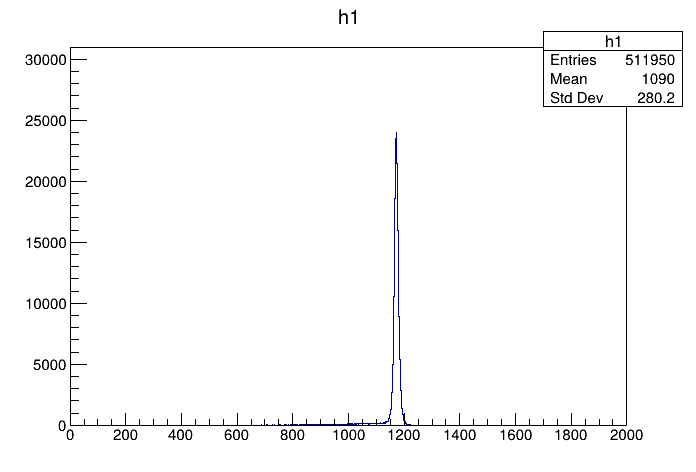

In [13]:
TCanvas *c1 = new TCanvas;
h1->Draw();
c1->Draw();

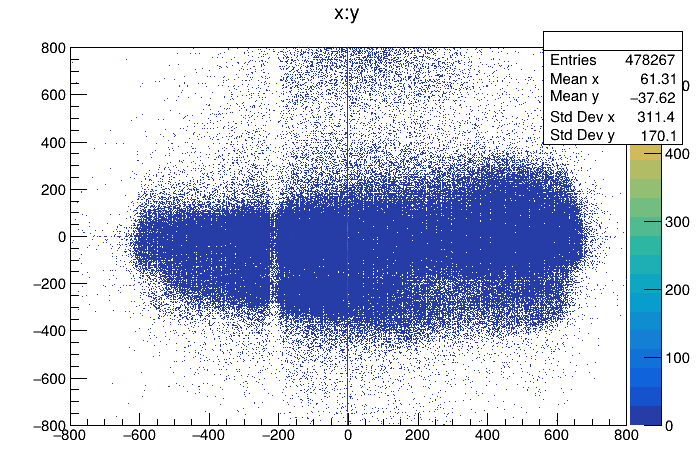

In [14]:
TFile *ipf1 = new TFile("ppac_demo.root");
TTree *tree1 = (TTree*) ipf1->Get("tree");
tree1->Draw("x:y>>(1000,-800,800,1000,-800,800)","","colz");
c1->Draw();


<hr/>
<h3 id="TChain%EF%BC%9A%E5%A4%84%E7%90%86%E5%A4%9A%E6%96%87%E4%BB%B6%E6%95%B0%E6%8D%AE%E9%93%BE">TChain：处理多文件数据链</h3><p>在物理实验中，数据通常分散在多个 run 文件中（如 <code>run0001.root</code> 到 <code>run0010.root</code>）。</p>
<p><strong><code>TChain</code> 对象是一个包含相同结构 TTree 的多个 ROOT 文件的列表。</strong>
由于 <code>TChain</code> 类继承自 <code>TTree</code> 类，在任何需要 <code>TTree*</code> 指针的地方（包括 <code>ppac</code> 类的构造函数），都可以直接使用 <code>TChain*</code> 指针。</p>
<p><strong>组装 TChain 示例：</strong></p>
<div class="highlight"><pre><span></span><span class="n">TChain</span><span class="w"> </span><span class="o">*</span><span class="n">chain</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="k">new</span><span class="w"> </span><span class="n">TChain</span><span class="p">(</span><span class="s">"tree"</span><span class="p">);</span><span class="w"> </span><span class="c1">// "tree" 是文件内部的 TTree 名称</span>
<span class="n">chain</span><span class="o">-&gt;</span><span class="n">Add</span><span class="p">(</span><span class="s">"run0001.root"</span><span class="p">);</span>
<span class="n">chain</span><span class="o">-&gt;</span><span class="n">Add</span><span class="p">(</span><span class="s">"run0002.root"</span><span class="p">);</span>
<span class="n">chain</span><span class="o">-&gt;</span><span class="n">Add</span><span class="p">(</span><span class="s">"run0003.root"</span><span class="p">);</span>

<span class="c1">// TChain 可直接调用 TTree 的方法，例如跨文件画图：</span>
<span class="c1">// chain-&gt;Draw("beamTrig");</span>
</pre></div>
<hr/>
<p>由于 <code>ppac</code> 类已经定义好了固定的数据结构，<strong>只要其他文件的内部 TTree 结构与 <code>ppac</code> 内定义的完全一致</strong>，我们就可以直接复用这个类来分析新文件，而无需重新生成代码。</p>
<h4 id="%E4%BD%BF%E7%94%A8-TChain-%E5%A4%84%E7%90%86%E6%96%87%E4%BB%B6%E9%93%BE">使用 TChain 处理文件链</h4><p>结合第 4 节的内容，将整个 <code>TChain</code> 传给分析类，实现自动化批处理。</p>
<div class="highlight"><pre><span></span><span class="n">root</span><span class="w"> </span><span class="p">[</span><span class="mi">0</span><span class="p">]</span><span class="w"> </span><span class="p">.</span><span class="n">L</span><span class="w"> </span><span class="n">ppac</span><span class="p">.</span><span class="n">C</span>
<span class="c1">// ... (此处省略定义 chain 和 Add 文件的代码)</span>
<span class="n">root</span><span class="w"> </span><span class="p">[</span><span class="mi">1</span><span class="p">]</span><span class="w"> </span><span class="n">ppac</span><span class="w"> </span><span class="n">t</span><span class="p">(</span><span class="n">chain</span><span class="p">);</span><span class="w"> </span><span class="c1">// 实例化：将包含了多个文件的链条传给构造函数</span>
<span class="n">root</span><span class="w"> </span><span class="p">[</span><span class="mi">2</span><span class="p">]</span><span class="w"> </span><span class="n">t</span><span class="p">.</span><span class="n">Loop</span><span class="p">();</span><span class="w">      </span><span class="c1">// 自动跨文件遍历整个链条的所有事件</span>
</pre></div>
<p><em>机制解析</em>：此时类内部的 <code>fChain</code> 指针指向整个文件链。在 <code>Loop()</code> 循环内部调用的 <code>LoadTree(entry)</code> 函数，会在当前文件读取完毕时，自动、无缝地打开下一个文件并更新地址状态。</p>
<hr/>
<p>重新生成 MakeClass 可能覆盖同名文件，修改前保留自己添加的分析代码；2.4 将演示用继承把生成代码与分析代码分开。TTreeReader 是 ROOT 中另一种带类型检查的读取方式，本章仍沿 MakeClass 的路线完成后续例子。</p>


<h3 id="%E6%80%BB%E7%BB%93">总结</h3><ul>
<li><strong>封装性</strong>：<code>ppac</code> 类将数百个变量和 <code>Init</code>、<code>Loop</code> 等方法封装在一起，形成一个独立的数据处理单元。</li>
<li><strong>可扩展性</strong>：用户可以在 <code>ppac.h</code> 中添加成员变量/函数，在 <code>ppac.C</code> 中实现逻辑。</li>
<li><strong>自动化</strong>：通过<strong>构造函数</strong>机制，实现了“实例化即绑定数据”，极大简化了分析流程。</li>
</ul>


<h2 id="assignment">作业</h2><p>用 MakeClass 读取前面的模拟数据，为探测器增加两端读出的薄 Veto Wall，按原练习的简化设定生成带电粒子的 veto 信号。比较应用 veto 条件前后的归一化 TOF—幅度二维图，不用 pid 作选择。</p><p>再把测量幅度、时间映射为 12-bit ADC/TDC 道值，保留原始量与状态。选定有效区间后重建位置和 TOF，比较 bin 中心取值与 1.3 的可选 dithering 结果。</p><p>Veto Wall 厚 1 cm，前后距离 5 cm；练习中设带电粒子沉积入射能量的 1/10，中子和 gamma 不产生 veto 信号，响应分辨采用前面的参数。这是该模拟的设定，不是实际探测效率的描述。</p><p><img alt="Veto Wall 与中子探测器" src="fig/vetowall.png"/></p>